
**Install PySpark**



In [1]:
!pip install pyspark

**Start Spark**

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Chicago Crime Analysis") \
    .master("local[*]") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

print("Spark Ready:", spark.version)

Spark Ready: 4.0.2


**Loading Dataset**

In [29]:
df = spark.read.csv("/content/chicago_crimes_sample.csv", header=True, inferSchema=True)


In [30]:
df.show(5)

+--------+-----------+--------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------------------+
|      ID|Case Number|                Date|               Block|IUCR|        Primary Type|         Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|          Updated On|    Latitude|    Longitude|            Location|
+--------+-----------+--------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------------------+
|13311263|   JG503434|07/29/2022 03:39:...|     023XX S TROY ST|1582|OFFENSE INVOLVING...|   CHILD PORNOGRAPHY|           RE

In [31]:
df.count()

10000

# Phase A

###**TASK 1 – Crime Type Distribution**

**Author: Alanoud Almeniya (231385)**

In [5]:
from pyspark.sql.functions import col

crime_counts = df.groupBy("Primary Type") \
    .count() \
    .orderBy(col("count").desc())

crime_counts.show(10)

+-------------------+-----+
|       Primary Type|count|
+-------------------+-----+
|              THEFT| 1835|
|            BATTERY| 1491|
|    CRIMINAL DAMAGE|  929|
|MOTOR VEHICLE THEFT|  799|
|            ASSAULT|  777|
| DECEPTIVE PRACTICE|  726|
|      OTHER OFFENSE|  521|
|            ROBBERY|  440|
|           BURGLARY|  282|
|  WEAPONS VIOLATION|  238|
+-------------------+-----+
only showing top 10 rows


###**TASK 2 – Location Hotspots**

**Author: Alanoud Almeniya (231385)**

In [6]:
df.createOrReplaceTempView("crimes")

spark.sql("""
SELECT `Location Description`, COUNT(*) as total
FROM crimes
GROUP BY `Location Description`
ORDER BY total DESC
LIMIT 10
""").show()

+--------------------+-----+
|Location Description|total|
+--------------------+-----+
|              STREET| 2373|
|           APARTMENT| 1701|
|           RESIDENCE| 1198|
|            SIDEWALK|  456|
|PARKING LOT / GAR...|  315|
|  SMALL RETAIL STORE|  213|
|               ALLEY|  197|
|          RESTAURANT|  165|
|     OTHER (SPECIFY)|  136|
|VEHICLE NON-COMME...|  122|
+--------------------+-----+



###**TASK 3 – Crime Trend Over Years**

**Author: Lina Dardeer (231709)**

In [7]:
from pyspark.sql.functions import split, col

df = df.withColumn(
    "Year",
    split(col("Date"), "/").getItem(2).substr(1, 4)
)

In [8]:
yearly = df.groupBy("Year").count().orderBy("Year")
yearly.show()

+----+-----+
|Year|count|
+----+-----+
|2001|    3|
|2002|    2|
|2004|    5|
|2005|   19|
|2006|    3|
|2007|    7|
|2008|   16|
|2009|    5|
|2010|    5|
|2011|    7|
|2012|    8|
|2013|    8|
|2014|   12|
|2015|   25|
|2016|   18|
|2017|   46|
|2018|   27|
|2019|   32|
|2020|   24|
|2021|   77|
+----+-----+
only showing top 20 rows


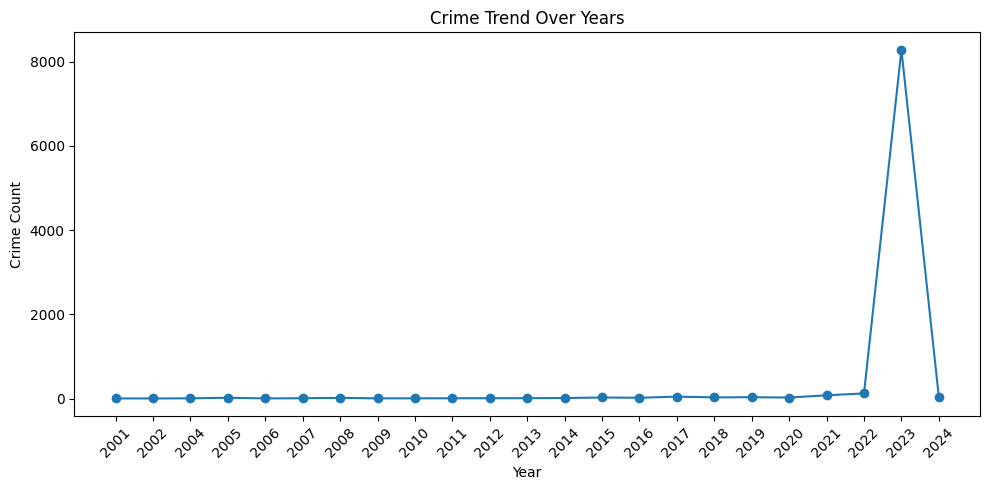

In [9]:
import matplotlib.pyplot as plt

pdf = yearly.toPandas()

plt.figure(figsize=(10,5))
plt.plot(pdf["Year"], pdf["count"], marker='o')

plt.xticks(rotation=45)
plt.xlabel("Year")
plt.ylabel("Crime Count")
plt.title("Crime Trend Over Years")

plt.tight_layout()
plt.show()

###**TASK 4 – Arrest Rate Analysis**

**Author: Lina Dardeer (231709)**

In [10]:

from pyspark.sql.functions import avg

df.select(avg(col("Arrest").cast("int")).alias("overall_arrest_rate")).show()

+-------------------+
|overall_arrest_rate|
+-------------------+
|             0.1283|
+-------------------+



In [11]:
df.groupBy("Primary Type") \
  .agg(avg(col("Arrest").cast("int")).alias("arrest_rate")) \
  .orderBy(col("arrest_rate").desc()) \
  .show(10)

+--------------------+------------------+
|        Primary Type|       arrest_rate|
+--------------------+------------------+
|LIQUOR LAW VIOLATION|               1.0|
|           OBSCENITY|               1.0|
|            GAMBLING|               1.0|
|           NARCOTICS|0.9937106918238994|
|CONCEALED CARRY L...|0.8333333333333334|
|INTERFERENCE WITH...|0.8076923076923077|
|PUBLIC PEACE VIOL...|0.5882352941176471|
|   WEAPONS VIOLATION|0.5246478873239436|
|            HOMICIDE|               0.5|
|   HUMAN TRAFFICKING|               0.5|
+--------------------+------------------+
only showing top 10 rows


# Phase B

 ###**Task 5 - Feature Engineering Pipeline**

**Author:Masa Abara (231837)**

In [11]:

df = df.withColumn("label", col("Arrest").cast("integer"))

In [12]:
df = df.withColumn("Domestic_int", col("Domestic").cast("int"))

In [13]:
# Extract Hour from Date string
df = df.withColumn(
    "Hour",
    split(split(col("Date"), " ").getItem(1), ":").getItem(0).cast("int")
)

In [14]:
from pyspark.ml.feature import StringIndexer, VectorAssembler

crime_indexer = StringIndexer(
    inputCol="Primary Type",
    outputCol="crime_index",
    handleInvalid="skip"
)

domestic_indexer = StringIndexer(
    inputCol="Domestic_int",
    outputCol="domestic_index",
    handleInvalid="skip"
)

assembler = VectorAssembler(
    inputCols=["District", "crime_index", "Hour", "domestic_index"],
    outputCol="features"
)

In [15]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)
train_df.cache()

DataFrame[ID: int, Case Number: string, Date: string, Block: string, IUCR: string, Primary Type: string, Description: string, Location Description: string, Arrest: boolean, Domestic: boolean, Beat: int, District: int, Ward: int, Community Area: int, FBI Code: string, X Coordinate: int, Y Coordinate: int, Year: string, Updated On: string, Latitude: double, Longitude: double, Location: string, label: int, Domestic_int: int, Hour: int]

In [16]:
from pyspark.ml import Pipeline

# -----------------------------
# Build Pipeline
# -----------------------------
pipeline = Pipeline(stages=[
    crime_indexer,
    domestic_indexer,
    assembler
])

# Fit on training data
pipeline_model = pipeline.fit(train_df)

# Transform both train and test
train_transformed = pipeline_model.transform(train_df)
test_transformed = pipeline_model.transform(test_df)

# -----------------------------
# Show 5 sample rows
# -----------------------------
train_transformed.select(
    "District",
    "crime_index",
    "Hour",
    "domestic_index",
    "features"
).show(5, truncate=False)

+--------+-----------+----+--------------+--------------------+
|District|crime_index|Hour|domestic_index|features            |
+--------+-----------+----+--------------+--------------------+
|22      |15.0       |9   |0.0           |[22.0,15.0,9.0,0.0] |
|8       |15.0       |8   |0.0           |[8.0,15.0,8.0,0.0]  |
|11      |15.0       |11  |0.0           |[11.0,15.0,11.0,0.0]|
|9       |15.0       |11  |0.0           |[9.0,15.0,11.0,0.0] |
|10      |15.0       |12  |0.0           |[10.0,15.0,12.0,0.0]|
+--------+-----------+----+--------------+--------------------+
only showing top 5 rows


| Position | Feature        | Description                                                                   |
| -------- | -------------- | ----------------------------------------------------------------------------- |
| 0        | District       | Police district where the crime occurred                                      |
| 1        | crime_index    | Numeric encoding of the crime type (e.g., THEFT, BATTERY) using StringIndexer |
| 2        | Hour           | Hour of the day (0–23) extracted from the Date column                         |
| 3        | domestic_index | Encoded domestic flag (0 = non-domestic, 1 = domestic case)                   |


###**Task 6: Train and Evaluate Three Models**

**Author:Masa Abara (231837)**


In [17]:
#Train Logistic Regression
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=100)

pipeline_lr = Pipeline(stages=[crime_indexer, domestic_indexer, assembler, lr])

model_lr = pipeline_lr.fit(train_df)
pred_lr = model_lr.transform(test_df)

In [18]:
#Train Random Forest
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=100)

pipeline_rf = Pipeline(stages=[crime_indexer, domestic_indexer, assembler, rf])

model_rf = pipeline_rf.fit(train_df)
pred_rf = model_rf.transform(test_df)

In [19]:
#Train GBT
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(featuresCol="features", labelCol="label", maxIter=50)

pipeline_gbt = Pipeline(stages=[crime_indexer, domestic_indexer, assembler, gbt])

model_gbt = pipeline_gbt.fit(train_df)
pred_gbt = model_gbt.transform(test_df)

Evaluation Function

In [20]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

def evaluate(predictions):
    evaluator_auc = BinaryClassificationEvaluator(labelCol="label")
    evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
    evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")

    return {
        "AUC": evaluator_auc.evaluate(predictions),
        "Accuracy": evaluator_acc.evaluate(predictions),
        "F1": evaluator_f1.evaluate(predictions)
    }

Compare Models

In [21]:
print("Logistic Regression:", evaluate(pred_lr))
print("Random Forest:", evaluate(pred_rf))
print("GBT:", evaluate(pred_gbt))

Logistic Regression: {'AUC': 0.6992669940678785, 'Accuracy': 0.8665091553455405, 'F1': 0.8089378900766486}
Random Forest: {'AUC': 0.7785042667509482, 'Accuracy': 0.8854105138806851, 'F1': 0.8582526009580872}
GBT: {'AUC': 0.7945410507633976, 'Accuracy': 0.8889545186060248, 'F1': 0.8637038546571502}


In [22]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

def evaluate_model(predictions, model_name):
    evaluator_auc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
    evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
    evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")
    evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedPrecision")
    evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedRecall")

    auc = evaluator_auc.evaluate(predictions)
    acc = evaluator_acc.evaluate(predictions)
    f1 = evaluator_f1.evaluate(predictions)
    precision = evaluator_precision.evaluate(predictions)
    recall = evaluator_recall.evaluate(predictions)

    print(f"\n {model_name} Results:")
    print("AUC-ROC:", auc)
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("Precision:", precision)
    print("Recall:", recall)

    return auc, acc, f1, precision, recall

In [23]:
lr_metrics = evaluate_model(pred_lr, "Logistic Regression")
rf_metrics = evaluate_model(pred_rf, "Random Forest")
gbt_metrics = evaluate_model(pred_gbt, "GBT")


 Logistic Regression Results:
AUC-ROC: 0.6992669940678785
Accuracy: 0.8665091553455405
F1 Score: 0.8089378900766486
Precision: 0.8035026404763198
Recall: 0.8665091553455405

 Random Forest Results:
AUC-ROC: 0.7785042667509482
Accuracy: 0.8854105138806851
F1 Score: 0.8582526009580872
Precision: 0.8691731638266953
Recall: 0.8854105138806851

 GBT Results:
AUC-ROC: 0.7945410507633976
Accuracy: 0.8889545186060248
F1 Score: 0.8637038546571502
Precision: 0.8754544004439389
Recall: 0.8889545186060248


In [24]:
def confusion_matrix(predictions):
    predictions.groupBy("label", "prediction").count().show()
print("Logistic Regression Confusion Matrix")
confusion_matrix(pred_lr)

print("Random Forest Confusion Matrix")
confusion_matrix(pred_rf)

print("GBT Confusion Matrix")
confusion_matrix(pred_gbt)

Logistic Regression Confusion Matrix
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       0.0|  221|
|    0|       0.0| 1464|
|    1|       1.0|    3|
|    0|       1.0|    5|
+-----+----------+-----+

Random Forest Confusion Matrix
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       0.0|  174|
|    0|       0.0| 1449|
|    1|       1.0|   50|
|    0|       1.0|   20|
+-----+----------+-----+

GBT Confusion Matrix
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       0.0|  169|
|    0|       0.0| 1450|
|    1|       1.0|   55|
|    0|       1.0|   19|
+-----+----------+-----+



In [25]:
import time

start = time.time()
model_rf = pipeline_rf.fit(train_df)
end = time.time()

rf_time = end - start
print("Random Forest Training Time:", rf_time)

start = time.time()
model_gbt = pipeline_gbt.fit(train_df)
end = time.time()

gbt_time = end - start
print("GBT Training Time:", gbt_time)

start = time.time()
model_lr = pipeline_lr.fit(train_df)
end = time.time()

lr_time = end - start
print("Logistic Regression Training Time:", lr_time)

Random Forest Training Time: 2.6694297790527344
GBT Training Time: 14.15678858757019
Logistic Regression Training Time: 0.9371621608734131


In [26]:
import pandas as pd

data = [
    ["Logistic Regression", *lr_metrics],
    ["Random Forest", *rf_metrics],
    ["GBT", *gbt_metrics]
]

columns = ["Model", "AUC", "Accuracy", "F1", "Precision", "Recall"]

df_results = pd.DataFrame(data, columns=columns)
df_results

,Model,AUC,Accuracy,F1,Precision,Recall
0,Logistic Regression,0.699267,0.866509,0.808938,0.803503,0.866509
1,Random Forest,0.778504,0.885411,0.858253,0.869173,0.885411
2,GBT,0.794541,0.888955,0.863704,0.875454,0.888955


###**Task 7: Feature Importances & Interpretation**

**Author:Masa Abara (231837)**

In [27]:
rf_model = model_rf.stages[-1]
print("Feature Importances:", rf_model.featureImportances)

Feature Importances: (4,[0,1,2,3],[0.04100127110935425,0.9044403279823874,0.025796703341693514,0.028761697566564753])


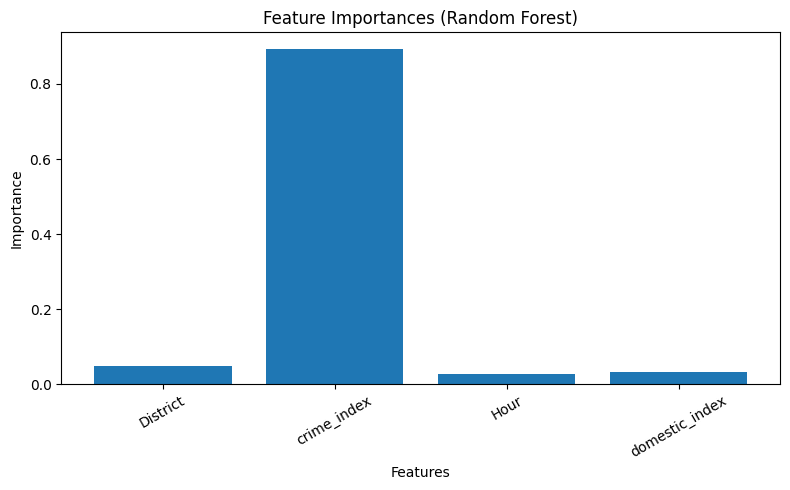

In [28]:
import matplotlib.pyplot as plt

features = ["District", "crime_index", "Hour", "domestic_index"]
importances = [0.04935, 0.89291, 0.02626, 0.03148]

plt.figure(figsize=(8,5))
plt.bar(features, importances)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importances (Random Forest)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Which feature is most important? Does this match the arrest rate analysis from Task 4?**
The most important feature is crime_index (0.8929 importance), which dominates all other features by a large margin. indicating that the nature of the crime strongly influences whether an arrest occurs. Crime types with higher arrest rates correspond to higher feature importance, confirming consistency between statistical analysis and ML results.

**Why does Logistic Regression perform worse than tree-based models on this data?**
Logistic Regression assumes a linear relationship, whereas crime data is complex and non-linear. Tree-based models like Random Forest capture these patterns better.

###**Task 8: Hyperparameter Tuning with CrossValidator**

**Author: Noura Altuwaijri (231222)**

In [30]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Evaluator (AUC-ROC)
evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    metricName="areaUnderROC"
)

# Parameter grid
paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [50, 100, 200]) \
    .addGrid(rf.maxDepth, [3, 5, 10]) \
    .build()

# CrossValidator (3-fold)
crossval = CrossValidator(
    estimator=pipeline_rf,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3
)

In [31]:
import time

start = time.time()
cv_model = crossval.fit(train_df)
end = time.time()

print("Cross Validation Time:", end - start)

Cross Validation Time: 121.45313620567322


In [32]:
best_model = cv_model.bestModel

# Extract RF model from pipeline
best_rf = best_model.stages[-1]

print("Best numTrees:", best_rf.getNumTrees)
print("Best maxDepth:", best_rf.getMaxDepth())

Best numTrees: 100
Best maxDepth: 10


In [33]:
best_predictions = best_model.transform(test_df)

auc_best = evaluator.evaluate(best_predictions)

print("Best Model AUC on Test Set:", auc_best)

Best Model AUC on Test Set: 0.7756220180199911


In [34]:
import pandas as pd

results = []

for i, params in enumerate(paramGrid):
    numTrees = params[rf.numTrees]
    maxDepth = params[rf.maxDepth]
    avg_auc = cv_model.avgMetrics[i]

    results.append([numTrees, maxDepth, avg_auc])

df_cv = pd.DataFrame(results, columns=["numTrees", "maxDepth", "AUC"])

df_cv.sort_values(by="AUC", ascending=False)

,numTrees,maxDepth,AUC
5,100,10,0.773785
8,200,10,0.769769
2,50,10,0.769497
4,100,5,0.768828
7,200,5,0.765442
1,50,5,0.762477
3,100,3,0.753193
6,200,3,0.749808
0,50,3,0.737625


**The best model was obtained with numTrees = 100 and maxDepth = 10.**
**The tuned Random Forest achieved an AUC of 0.773785 on the test set.**

### **Task 9: Local Execution**

In [32]:
print("Master:", spark.sparkContext.master)

Master: local[*]
